In [2]:
# .seed() [The seed is used to make your model’s results repeatable and consistent.]  [This ensures the results are always the same when you run the code again.]

# Controls Python’s built-in randomness
import random
random.seed(0)

# Controls NumPy’s randomness
import numpy as np
np.random.seed(0)


# Controls TensorFlow’s randomness (used in model training)
import tensorflow as tf
tf.random.set_seed(0)

In [3]:
from tensorflow .keras import datasets, layers, models
import matplotlib.pyplot as plt

## Load the dataset

In [4]:
fashion_mnist = datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

In [5]:
type(train_images)

numpy.ndarray

In [6]:
print(len(train_images))
print(len(test_images))

60000
10000


In [7]:
print(train_images[0].shape)

(28, 28)


In [8]:
# each image is in numpy array format
# shape of one image : (28,28) 

In [9]:
print(train_images[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1   1   0 200 232 23

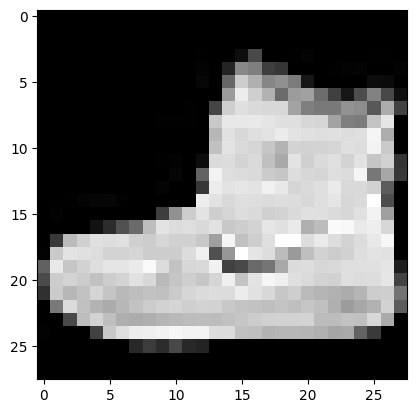

Label:  9


In [10]:
# Display an image from the dataset
plt.imshow(train_images[0], cmap = 'gray')
plt.show()


# the label corresponding to the image
print("Label: ", train_labels[0])

### class_names = ["T-shirt/Top", "Trouser", "Pullover", "Dress", "Coat","Sandal", "Shirt", "Sneaker", "Bag", "Ankle Boot"]

In [11]:
# Normalise pixel values to be between 0 and 1
train_images , test_images = train_images/255.0 , test_images/255.0

In [12]:
# Reshaping  (keras and tensorflow models require data to be 4-Dimensional)
train_images = train_images.reshape((train_images.shape[0], 28, 28 ,1))   # since image is grayscale , the no. of channel is 1
test_images = test_images.reshape((test_images.shape[0], 28, 28 ,1))

In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

datagen.fit(train_images)

## CNN

In [14]:
# Convolutional Base 
model = models.Sequential()
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(layers.BatchNormalization())
model.add(layers.MaxPool2D((2,2)))
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPool2D((2,2)))
model.add(layers.Conv2D(64, (3,3), activation='relu'))



# Adding dense layers
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dropout(0.5))    # dropping 50% neurons to avoid overfitting
model.add(layers.Dense(10, activation='softmax'))



c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Model training


In [16]:
history = model.fhistory = model.fit(
    datagen.flow(train_images, train_labels, batch_size=32),
    epochs=15,
    validation_data=(test_images, test_labels)
)

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - accuracy: 0.7262 - loss: 0.7379 - val_accuracy: 0.8076 - val_loss: 0.5020
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.8009 - loss: 0.5358 - val_accuracy: 0.8423 - val_loss: 0.4232
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.8239 - loss: 0.4780 - val_accuracy: 0.8590 - val_loss: 0.3786
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.8362 - loss: 0.4479 - val_accuracy: 0.8633 - val_loss: 0.3735
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.8465 - loss: 0.4237 - val_accuracy: 0.8699 - val_loss: 0.3595
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.8519 - loss: 0.4075 - val_accuracy: 0.8764 - val_loss: 0.3371
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.8578 - loss: 0.3966 - val_accuracy: 0.8725 - val_loss: 0.3457
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.8594 -

## Model evaluation

In [17]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)  #verbose how much information is displayed during training or evaluation in Keras. [2 means One-Line Per Epoch]
print("\nTest accuracy", test_acc)

313/313 - 1s - 2ms/step - accuracy: 0.8931 - loss: 0.3050

Test accuracy 0.8931000232696533


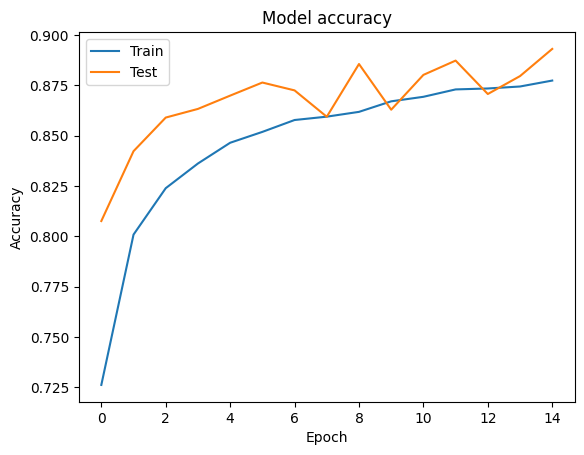

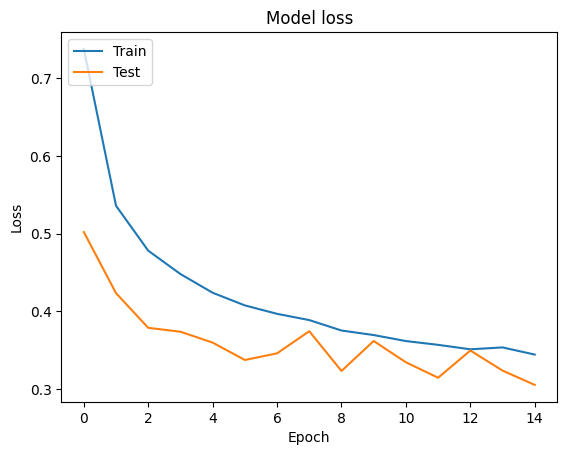

In [18]:
# Plotting training and validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc = 'upper left')
plt.show()



# Plotting training and validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc = 'upper left')
plt.show()


In [19]:
# model.save(r'C:\Users\HP\OneDrive\Documents\Etc\FashionMNIST\trained_fashionMNIST_model.keras')
# import os

# save_path = r"C:\Users\HP\Desktop\trained_fashionMNIST_model.keras"
# model.save(save_path)

# print("Model saved at:", save_path)
# print("File exists:", os.path.exists(save_path))
import os

save_dir = r"C:\Users\HP\Desktop"
os.makedirs(save_dir, exist_ok=True)  # Ensures the folder exists

save_path = os.path.join(save_dir, "trained_fashionMNIST_model.keras")
model.save(save_path)

print("Model saved at:", save_path)
print("File exists:", os.path.exists(save_path))

Model saved at: C:\Users\HP\Desktop\trained_fashionMNIST_model.keras
File exists: True


In [20]:
import os

print(os.path.exists(r"C:\Users\HP\Desktop"))

True


In [21]:
from tensorflow.keras.datasets import fashion_mnist
import numpy as np

(_, _), (test_images, test_labels) = fashion_mnist.load_data()

test_images = test_images / 255.0
test_images = test_images.reshape(-1, 28, 28, 1)

predictions = model.predict(test_images[:10])
predicted_labels = np.argmax(predictions, axis=1)

print("Predicted:", predicted_labels)
print("Actual:   ", test_labels[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Predicted: [9 2 1 1 6 1 4 6 5 7]
Actual:    [9 2 1 1 6 1 4 6 5 7]
